In [3]:
import pandas as pd
import numpy as np
import utils


检测到输入df的经纬度信息不完整，自动从position_csv_path读取并合并...


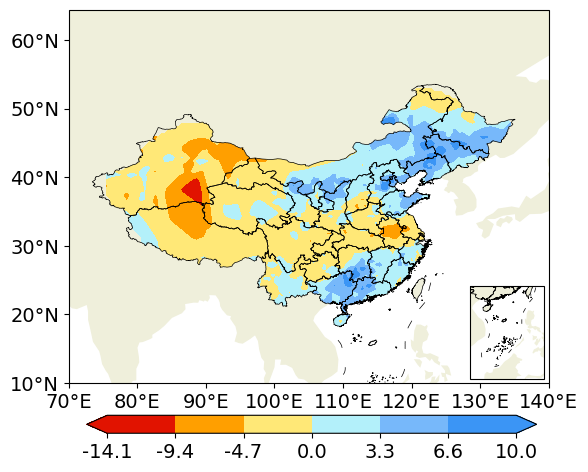

In [4]:
df = pd.read_csv('./data2/pre/1994.csv')
grid = utils.gred_time_site_to_net(df, to_xr=False, gred_var='prep')
utils.draw_rainfall_map(grid[0]*100)


In [5]:
import os
import glob
import pandas as pd

# Mean precipitation per station from training dataset
obs_df = pd.read_csv('./data2/summer_pr.csv')
mean_precip = obs_df.groupby('Stn_No')['Precip'].mean()

# Read predicted anomaly percentage files and restore precipitation
pre_dir = './data2/pre'
out_dir = './data2/pre_ano'
os.makedirs(out_dir, exist_ok=True)

for path in sorted(glob.glob(os.path.join(pre_dir, '*.csv'))):
    df = pd.read_csv(path)
    # df columns: time, Stn_No, prep (anomaly percentage as fraction)
    df['Precip'] = df.apply(lambda r: mean_precip[r['Stn_No']] * (1 + r['prep']), axis=1)
    out_path = os.path.join(out_dir, os.path.basename(path))
    df[['time', 'Stn_No', 'Precip']].to_csv(out_path, index=False)

print(f'Wrote restored precipitation files to: {out_dir}')


Wrote restored precipitation files to: ./data2/pre_ano
